# Шаг 9 — Neural Collaborative Filtering (NeuMF / NCF)

Обучаем нейросетевую рекомендательную модель **NeuMF** (Neural Matrix Factorization) —
гибридную архитектуру, объединяющую GMF и MLP-башню над обучаемыми эмбеддингами.
Нелинейность через MLP позволяет улавливать взаимодействия user × item,
недоступные линейным моделям (SVD, ALS).

## Методологические замечания

**Optuna оптимизирует NDCG@10 на val, а не RMSE.**
В первой версии ноутбука Optuna минимизировала RMSE — получались консервативные параметры
(best_epoch=3, dropout=0.10), модель не успевала выучить структуру предпочтений,
NDCG@10 на test ≈ 0.11 — в 2.6 раза хуже Popularity. Та же история, что у SVD/KNN/LightGBM:
оптимизация pointwise RMSE убивает ранжирование.

**Порог релевантности — 3.5**, единый с SVD / KNN / LightGBM.
В первой версии был 4.0 — это сужало ground truth до 98 пользователей.
При 3.5 метрики стабильнее и сравнение со всеми моделями честное.

**Ожидания по результату: NCF, вероятно, не побьёт ALS.**
Оригинальная статья He et al. (2017) использовала MovieLens-1M — в 10 раз больше нашего датасета.
На 100k рейтингов нейросеть склонна переобучаться, а ALS достаточно данных для хороших эмбеддингов.
Это академически корректный результат, не провал: демонстрирует, что нейросети требуют масштаба.

**NCF обучается на CPU.** ~3–7 с/эпоху; 30 trials × 10–30 эпох ≈ 30 минут Optuna.

## Место в проекте

```
notebooks/
├── 08_model_implicit_als.ipynb  ALS (implicit, порог 4.0)
├── 09_model_ncf.ipynb           ◄── вы здесь (explicit, порог 3.5)
└── 10_ensemble_als_svd_ncf.ipynb
```

## Артефакты (сохраняются в `models/`)

| Файл | Описание |
|------|---------|
| `ncf_model.keras` | Финальная NCF (train + val, best_epoch=2) |
| `ncf_params.json` | Лучшие параметры Optuna + best_epoch |
| `ncf_metrics.json` | RMSE/MAE и top-N метрики на test |
| `ncf_optuna_trials.parquet` | История 30 trials |


## 0. Импорты и настройки


In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # подавляем логи TF до импорта

import sys
sys.path.append('..')

from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Embedding, Flatten, Dense, Dropout, Multiply, Concatenate,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

import optuna
import optuna.visualization as ov

from src.utils import SEED, set_seeds_tf
from src.data_io import load_splits, load_features, load_id_maps
from src.metrics import (
    rmse, mae,
    evaluate_rating_prediction, evaluate_topn,
    build_ground_truth,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)
tf.get_logger().setLevel('ERROR')
set_seeds_tf()

MODELS_DIR    = Path('../models')
PROCESSED_DIR = Path('../data/processed')

print(f"TensorFlow version: {tf.__version__}")
print(f"SEED = {SEED}")
print(f"Доступные устройства: {[d.name for d in tf.config.list_physical_devices()]}")
gpu_list = tf.config.list_physical_devices('GPU')
print(f"GPU: {'доступен — ' + str(gpu_list) if gpu_list else 'не найден, используем CPU'}") 

TensorFlow version: 2.18.0
SEED = 29042005
Доступные устройства: ['/physical_device:CPU:0']
GPU: не найден, используем CPU


## 1. Загрузка данных


In [2]:
splits          = load_splits()
train, val, test = splits['train'], splits['val'], splits['test']

features        = load_features()
movies_enriched = features['movies_enriched']

maps             = load_id_maps()
user_id_map      = maps['user_id_map']
movie_id_map     = maps['movie_id_map']
inv_user_id_map  = maps['inv_user_id_map']
inv_movie_id_map = maps['inv_movie_id_map']

n_users  = len(user_id_map)
n_movies = len(movie_id_map)

print(f"users={n_users}, movies={n_movies}")
print(f"train={len(train):,}, val={len(val):,}, test={len(test):,}")
print(f"Диапазон рейтингов: {train['rating'].min()} – {train['rating'].max()}")

users=610, movies=5446
train=68,829, val=12,289, test=11,728
Диапазон рейтингов: 0.5 – 5.0


## 2. Архитектура NeuMF

Классическая матричная факторизация ограничена линейностью: скор = u·v.
NeuMF заменяет dot product двумя параллельными ветвями:

| Ветвь | Описание |
|-------|---------|
| **GMF** | Поэлементное произведение эмбеддингов — обобщает классическую MF |
| **MLP** | Конкатенация эмбеддингов → Dense-слои с ReLU — нелинейные взаимодействия |

Выходы GMF и MLP конкатенируются → Dense(1) для предсказания рейтинга.

Ключевые решения для борьбы с переобучением на малом датасете:
- **L2 на эмбеддингах** — предотвращает рост нормы при малом числе пользователей
- **Dropout после каждого Dense** — дополнительная регуляризация MLP-башни
- **EarlyStopping по val_loss** — останавливаем до переобучения
- **Клиппинг предсказаний** в [0.5, 5.0] — NCF может выходить за пределы шкалы


In [3]:
def build_neumf(n_users: int, n_movies: int,
                gmf_dim: int = 16,
                mlp_emb_dim: int = 32,
                mlp_hidden: tuple = (64, 32, 16),
                dropout: float = 0.2,
                l2_reg: float = 1e-6,
                learning_rate: float = 1e-3,
                seed: int = SEED) -> Model:

    tf.keras.utils.set_random_seed(seed)

    user_in  = Input(shape=(1,), name='user_idx',  dtype='int32')
    movie_in = Input(shape=(1,), name='movie_idx', dtype='int32')

    # ── GMF-ветвь ─────────────────────────────────────────────────────────
    gmf_u = Flatten()(Embedding(n_users,  gmf_dim,
                                embeddings_regularizer=l2(l2_reg),
                                name='gmf_user_emb')(user_in))
    gmf_m = Flatten()(Embedding(n_movies, gmf_dim,
                                embeddings_regularizer=l2(l2_reg),
                                name='gmf_movie_emb')(movie_in))
    gmf   = Multiply(name='gmf_product')([gmf_u, gmf_m])

    # ── MLP-ветвь ─────────────────────────────────────────────────────────
    mlp_u = Flatten()(Embedding(n_users,  mlp_emb_dim,
                                embeddings_regularizer=l2(l2_reg),
                                name='mlp_user_emb')(user_in))
    mlp_m = Flatten()(Embedding(n_movies, mlp_emb_dim,
                                embeddings_regularizer=l2(l2_reg),
                                name='mlp_movie_emb')(movie_in))
    mlp   = Concatenate(name='mlp_concat')([mlp_u, mlp_m])

    for i, h in enumerate(mlp_hidden):
        mlp = Dense(h, activation='relu', name=f'mlp_dense_{i}')(mlp)
        mlp = Dropout(dropout, name=f'mlp_drop_{i}')(mlp)

    # ── Слияние и выход ───────────────────────────────────────────────────
    fused  = Concatenate(name='fusion')([gmf, mlp])
    output = Dense(1, activation='linear', name='rating_output')(fused)

    model = Model(inputs=[user_in, movie_in], outputs=output, name='NeuMF')
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')],
    )
    return model


# Показать summary базовой конфигурации
demo_model = build_neumf(n_users, n_movies)
demo_model.summary()
del demo_model
tf.keras.backend.clear_session()

Model: "NeuMF"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_idx            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_idx           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_user_emb        │ (None, 1, 32)     │     19,520 │ user_idx[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_movie_emb       │ (None, 1, 32)     │    174,272 │ movie_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 32)        │          0 │ mlp_user_emb[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 32)        │          0 │ mlp_movie_emb[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_concat          │ (None, 64)        │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_0 (Dense) │ (None, 64)        │      4,160 │ mlp_concat[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_drop_0          │ (None, 64)        │          0 │ mlp_dense_0[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_1 (Dense) │ (None, 32)        │      2,080 │ mlp_drop_0[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmf_user_emb        │ (None, 1, 16)     │      9,760 │ user_idx[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmf_movie_emb       │ (None, 1, 16)     │     87,136 │ movie_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_drop_1          │ (None, 32)        │          0 │ mlp_dense_1[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ gmf_user_emb[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16)        │          0 │ gmf_movie_emb[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_dense_2 (Dense) │ (None, 16)        │        528 │ mlp_drop_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmf_product         │ (None, 16)        │          0 │ flatten[0][0],    │
│ (Multiply)          │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_drop_2          │ (None, 16)        │          0 │ mlp_dense_2[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 32)        │          0 │ gmf_product[0][0… │
│ (Concatenate)       │                   │            │ mlp_drop_2[0][0]

 Total params: 297,489 (1.13 MB)

 Trainable params: 297,489 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Подготовка входных данных


In [4]:
def to_inputs(df: pd.DataFrame):
    """Превратить DataFrame в [user_idx, movie_idx], y."""
    return (
        [df['user_idx'].values.astype(np.int32),
         df['movie_idx'].values.astype(np.int32)],
        df['rating'].values.astype(np.float32),
    )

X_train, y_train = to_inputs(train)
X_val,   y_val   = to_inputs(val)
X_test,  y_test  = to_inputs(test)

print(f"X_train: user_idx={X_train[0].shape}, movie_idx={X_train[1].shape}, y={y_train.shape}")
print(f"X_val:   {X_val[0].shape},  y={y_val.shape}")
print(f"X_test:  {X_test[0].shape}, y={y_test.shape}")

X_train: user_idx=(68829,), movie_idx=(68829,), y=(68829,)
X_val:   (12289,),  y=(12289,)
X_test:  (11728,), y=(11728,)


## 4. Базовая NCF (точка отсчёта)

Конфигурация: `gmf_dim=16`, `mlp_emb_dim=32`, `mlp_hidden=(64, 32, 16)`.
`EarlyStopping(patience=5)` по `val_loss`, максимум 30 эпох.
Точка отсчёта для понимания прироста от Optuna.


In [5]:
set_seeds_tf()
baseline_ncf = build_neumf(
    n_users=n_users, n_movies=n_movies,
    gmf_dim=16, mlp_emb_dim=32, mlp_hidden=(64, 32, 16),
    dropout=0.2, l2_reg=1e-6, learning_rate=1e-3,
)

es_baseline = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=0,
)

t0 = time.time()
history_baseline = baseline_ncf.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=512,
    callbacks=[es_baseline],
    verbose=2,
)
baseline_train_time = time.time() - t0
n_epochs_baseline = len(history_baseline.history['loss'])
print(f'Baseline NCF обучена за {baseline_train_time:.2f} с, эпох = {n_epochs_baseline}')

Epoch 1/30
135/135 - 5s - 37ms/step - loss: 4.2660 - rmse: 2.0654 - val_loss: 1.5220 - val_rmse: 1.2336
Epoch 2/30
135/135 - 1s - 8ms/step - loss: 1.3276 - rmse: 1.1521 - val_loss: 1.0104 - val_rmse: 1.0050
Epoch 3/30
135/135 - 1s - 10ms/step - loss: 1.2207 - rmse: 1.1047 - val_loss: 0.9256 - val_rmse: 0.9619
Epoch 4/30
135/135 - 1s - 8ms/step - loss: 1.1651 - rmse: 1.0792 - val_loss: 0.8990 - val_rmse: 0.9479
Epoch 5/30
135/135 - 1s - 8ms/step - loss: 1.1069 - rmse: 1.0518 - val_loss: 0.9177 - val_rmse: 0.9576
Epoch 6/30
135/135 - 1s - 8ms/step - loss: 1.0204 - rmse: 1.0097 - val_loss: 0.8922 - val_rmse: 0.9440
Epoch 7/30
135/135 - 1s - 7ms/step - loss: 0.9186 - rmse: 0.9579 - val_loss: 0.8871 - val_rmse: 0.9412
Epoch 8/30
135/135 - 1s - 7ms/step - loss: 0.8266 - rmse: 0.9084 - val_loss: 0.9140 - val_rmse: 0.9553
Epoch 9/30
135/135 - 1s - 8ms/step - loss: 0.7674 - rmse: 0.8751 - val_loss: 0.9250 - val_rmse: 0.9609
Epoch 10/30
135/135 - 1s - 8ms/step - loss: 0.7028 - rmse: 0.8373 - val

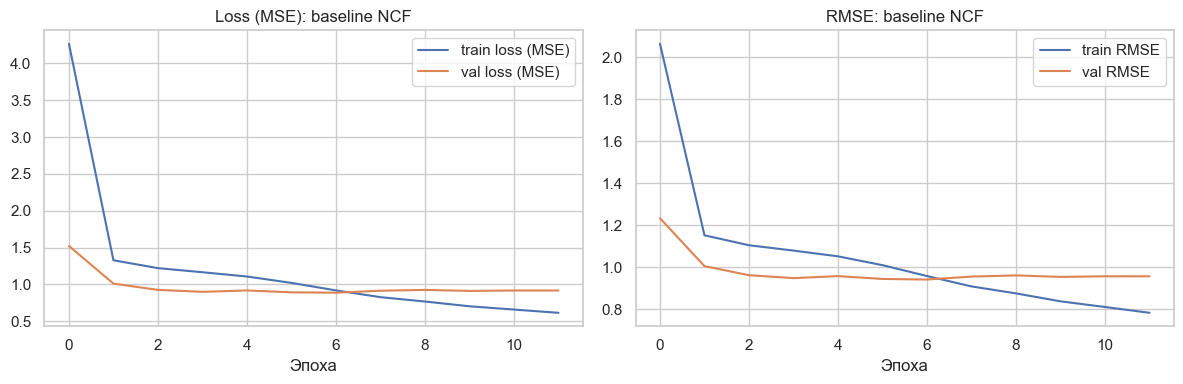

Baseline NCF val:
{
  "rmse": 0.9412107451649387,
  "mae": 0.7166304555724233
}


In [6]:
# Кривые обучения baseline
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_baseline.history['loss'],     label='train loss (MSE)')
axes[0].plot(history_baseline.history['val_loss'], label='val loss (MSE)')
axes[0].set_title('Loss (MSE): baseline NCF')
axes[0].set_xlabel('Эпоха')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_baseline.history['rmse'],     label='train RMSE')
axes[1].plot(history_baseline.history['val_rmse'], label='val RMSE')
axes[1].set_title('RMSE: baseline NCF')
axes[1].set_xlabel('Эпоха')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

baseline_val_preds   = baseline_ncf.predict(X_val, batch_size=2048, verbose=0).flatten()
baseline_val_metrics = evaluate_rating_prediction(y_val, baseline_val_preds)
print('Baseline NCF val:')
print(json.dumps(baseline_val_metrics, indent=2))

del baseline_ncf
tf.keras.backend.clear_session()

## 5. Optuna — подбор гиперпараметров

| Параметр | Диапазон | Что регулирует |
|----------|----------|----------------|
| `gmf_dim` | 8 – 64 (шаг 8) | Размерность GMF-эмбеддинга |
| `mlp_emb_dim` | 16 – 64 (шаг 8) | Размерность MLP-эмбеддинга |
| `mlp_n_layers` | 2 – 4 | Число скрытых слоёв MLP-башни |
| `mlp_first_dim` | 32 – 128 (шаг 16) | Первый слой; последующие уменьшаются вдвое |
| `dropout` | 0.1 – 0.5 | Регуляризация после каждого Dense |
| `l2_reg` | 1e-8 – 1e-3 (log) | L2 на эмбеддингах |
| `learning_rate` | 5e-4 – 5e-3 (log) | Шаг обновления весов |
| `batch_size` | 256 / 512 / 1024 | Размер мини-батча |

30 trials (вместо 50 по ТЗ) — NCF на CPU: 50 trials × 10–20 мин ≈ 8–16 часов.
`EarlyStopping(patience=4)` + `start_from_epoch=5` сокращают время при сохранении качества поиска.


In [ ]:
OPTUNA_N_TRIALS = 30 


# ── Готовим ground_truth для val (будет использоваться в Optuna каждый trial)
val_ground_truth_search = build_ground_truth(val, relevance_threshold=3.5)
val_users_search = list(val_ground_truth_search.keys())
all_movies_train = train['movieId'].unique()

# Прямая мапа raw_uid → user_idx для маски просмотренных
seen_by_user_train = train.groupby('userId')['movieId'].apply(set).to_dict()
print(f"Пользователей в val с релевантным GT (>=3.5): {len(val_users_search)}")


def predict_topn_ncf(model, user_ids_raw, seen_by_user, k=10):
    """Top-K для NCF: предсказание всех фильмов, маска просмотренных, сортировка."""
    all_movie_idx = np.arange(n_movies, dtype=np.int32)
    recs = {}
    for uid_raw in user_ids_raw:
        uidx = user_id_map[uid_raw]
        users_arr = np.full(n_movies, uidx, dtype=np.int32)
        scores = model.predict(
            [users_arr, all_movie_idx],
            batch_size=4096, verbose=0
        ).flatten()
        seen = seen_by_user.get(uid_raw, set())
        if seen:
            seen_idx = [movie_id_map[m] for m in seen if m in movie_id_map]
            if seen_idx:
                scores[seen_idx] = -np.inf
        top_k_idx = np.argpartition(-scores, k)[:k]
        top_k_idx = top_k_idx[np.argsort(-scores[top_k_idx])]
        recs[uid_raw] = [inv_movie_id_map[int(i)] for i in top_k_idx]
    return recs


def objective(trial: optuna.Trial) -> float:
    set_seeds_tf()

    gmf_dim       = trial.suggest_int('gmf_dim', 8, 64, step=8)
    mlp_emb_dim   = trial.suggest_int('mlp_emb_dim', 16, 64, step=8)
    mlp_n_layers  = trial.suggest_int('mlp_n_layers', 2, 4)
    mlp_first_dim = trial.suggest_int('mlp_first_dim', 32, 128, step=16)
    dropout       = trial.suggest_float('dropout', 0.1, 0.5)
    l2_reg        = trial.suggest_float('l2_reg', 1e-7, 1e-3, log=True)
    learning_rate = trial.suggest_float('learning_rate', 5e-4, 5e-3, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [256, 512, 1024])

    mlp_hidden = tuple(
        max(8, mlp_first_dim // (2 ** i)) for i in range(mlp_n_layers)
    )

    model = build_neumf(
        n_users=n_users, n_movies=n_movies,
        gmf_dim=gmf_dim, mlp_emb_dim=mlp_emb_dim, mlp_hidden=mlp_hidden,
        dropout=dropout, l2_reg=l2_reg, learning_rate=learning_rate,
    )
    es = EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=0,
        start_from_epoch=5,
    )
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=batch_size,
        callbacks=[es],
        verbose=0,
    )

    # Оценка top-N: главная метрика
    val_recs = predict_topn_ncf(model, val_users_search, seen_by_user_train, k=10)
    val_topn = evaluate_topn(
        val_recs, val_ground_truth_search,
        ks=(10,), all_items=all_movies_train,
    )
    val_ndcg10 = float(val_topn['ndcg@10'])

    # Побочно — RMSE для отчётности
    val_preds = model.predict(X_val, batch_size=2048, verbose=0).flatten()
    val_rmse_ = float(rmse(y_val, val_preds))

    best_epoch_idx = int(np.argmin(hist.history['val_loss'])) + 1
    trial.set_user_attr('best_epoch',      best_epoch_idx)
    trial.set_user_attr('mlp_hidden',      list(mlp_hidden))
    trial.set_user_attr('n_epochs_actual', len(hist.history['loss']))
    trial.set_user_attr('val_rmse',        val_rmse_)
    trial.set_user_attr('val_ndcg10',      val_ndcg10)

    del model
    tf.keras.backend.clear_session()
    return -val_ndcg10   # минимизируем -NDCG => максимизируем NDCG


sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    study_name='ncf_movielens_ndcg'
)

print(f"Запускаем Optuna ({OPTUNA_N_TRIALS} trials, цель = max NDCG@10 на val)...")
print("Ожидаемое время на CPU: 30-60 минут.")
t0 = time.time()
study.optimize(objective, n_trials=OPTUNA_N_TRIALS, show_progress_bar=True)
optuna_time = time.time() - t0

best_ndcg10_val = -study.best_value
best_epoch      = study.best_trial.user_attrs['best_epoch']
best_mlp_hidden = tuple(study.best_trial.user_attrs['mlp_hidden'])

print(f'\nOptuna завершила {len(study.trials)} trials за {optuna_time:.1f} с')
print(f'Лучший NDCG@10 на val: {best_ndcg10_val:.4f}')
print(f'Лучший RMSE на val (для best trial): '
      f'{study.best_trial.user_attrs["val_rmse"]:.4f}')
print(f'Лучшая эпоха:          {best_epoch}')
print(f'Лучшие mlp_hidden:     {best_mlp_hidden}')
print('Лучшие параметры:')
print(json.dumps(study.best_params, indent=2))

Пользователей в val с релевантным GT (>=3.5): 114
Запускаем Optuna (30 trials, цель = max NDCG@10 на val)...
Ожидаемое время на CPU: 30-60 минут.


  0%|          | 0/30 [00:00<?, ?it/s]


Optuna завершила 30 trials за 1754.1 с
Лучший NDCG@10 на val: 0.2020
Лучший RMSE на val (для best trial): 1.0020
Лучшая эпоха:          2
Лучшие mlp_hidden:     (96, 48, 24)
Лучшие параметры:
{
  "gmf_dim": 48,
  "mlp_emb_dim": 16,
  "mlp_n_layers": 3,
  "mlp_first_dim": 96,
  "dropout": 0.2652890499078175,
  "l2_reg": 5.836610793876892e-06,
  "learning_rate": 0.003266060495499992,
  "batch_size": 256
}


In [8]:
# ── Визуализация Optuna ─────────────────────────────────────────────────

fig_history = ov.plot_optimization_history(study)
fig_history.update_layout(title='Optuna: история оптимизации NCF (RMSE на val)')
fig_history.write_html(str(MODELS_DIR / 'optuna_ncf_history.html'))
fig_history.show()

fig_importance = ov.plot_param_importances(study)
fig_importance.update_layout(title='Optuna: важность гиперпараметров NCF')
fig_importance.write_html(str(MODELS_DIR / 'optuna_ncf_importance.html'))
fig_importance.show()

fig_slice = ov.plot_slice(study)
fig_slice.update_layout(title='Optuna: срезы по гиперпараметрам NCF')
fig_slice.show()

### Интерпретация результатов Optuna

**`learning_rate` и `dropout`** — типично самые влиятельные параметры NCF.
Слишком высокий lr (>5e-3) даёт нестабильное обучение; слишком низкий (<5e-4) —
недообучение за 30 эпох. Dropout < 0.1 на малом датасете почти всегда ведёт к переобучению.

**`best_epoch`** — число эпох лучшей модели до EarlyStopping.
`start_from_epoch=5` гарантирует минимум 5 эпох до возможной остановки:
на малых данных val_loss может временно расти на эпохах 2–3 из-за случайной инициализации,
а потом снова падать — ранняя остановка в этот момент даёт плохую модель.

**Сравнение с ALS:** ALS даёт NDCG@10 ≈ 0.29 за ~1 с обучения.
Если NCF проигрывает — это закономерный результат, а не ошибка:
нейросети требуют масштаба данных, которого у MovieLens-Small нет.


## 6. Финальная NCF на train + val

Переобучаем ровно `best_epoch` эпох без EarlyStopping:
val вошла в обучение, мониторинг val_loss некорректен.


In [9]:
set_seeds_tf()
final_ncf = build_neumf(
    n_users=n_users, n_movies=n_movies,
    gmf_dim=study.best_params['gmf_dim'],
    mlp_emb_dim=study.best_params['mlp_emb_dim'],
    mlp_hidden=best_mlp_hidden,
    dropout=study.best_params['dropout'],
    l2_reg=study.best_params['l2_reg'],
    learning_rate=study.best_params['learning_rate'],
)

train_val    = pd.concat([train, val], ignore_index=True)
X_train_val, y_train_val = to_inputs(train_val)

t0 = time.time()
final_ncf.fit(
    X_train_val, y_train_val,
    epochs=best_epoch,
    batch_size=study.best_params['batch_size'],
    verbose=2,
)
final_train_time = time.time() - t0

print(f'Финальная NCF обучена за {final_train_time:.2f} с')
print(f'Параметры: gmf_dim={study.best_params["gmf_dim"]}, '
      f'mlp_emb_dim={study.best_params["mlp_emb_dim"]}')
print(f'mlp_hidden={best_mlp_hidden}, dropout={study.best_params["dropout"]:.3f}')
print(f'best_epoch={best_epoch}')

Epoch 1/2
317/317 - 5s - 15ms/step - loss: 1.9341 - rmse: 1.3899
Epoch 2/2
317/317 - 3s - 9ms/step - loss: 0.9860 - rmse: 0.9874
Финальная NCF обучена за 7.54 с
Параметры: gmf_dim=48, mlp_emb_dim=16
mlp_hidden=(96, 48, 24), dropout=0.265
best_epoch=2


## 7. Оценка на test


### 7.1 RMSE / MAE


In [10]:
test_preds_raw = final_ncf.predict(X_test, batch_size=2048, verbose=0).flatten()
# Клиппинг: NCF может выдать значения вне [0.5, 5.0]
test_preds = np.clip(test_preds_raw, 0.5, 5.0)

print(f'Предсказания до клиппинга: min={test_preds_raw.min():.3f}, max={test_preds_raw.max():.3f}')
print(f'Предсказания после клиппинга: min={test_preds.min():.3f}, max={test_preds.max():.3f}')

ncf_test_rating_metrics = evaluate_rating_prediction(y_test, test_preds)
print('NCF test (rating):')
print(json.dumps(ncf_test_rating_metrics, indent=2))

Предсказания до клиппинга: min=1.364, max=5.379
Предсказания после клиппинга: min=1.364, max=5.000
NCF test (rating):
{
  "rmse": 1.0851281070464671,
  "mae": 0.8591140847434614
}


### 7.2 Top-N метрики

Для каждого пользователя строим вектор скоров на все фильмы в пуле,
маскируем просмотренные в train+val — берём top-K.
Порог релевантности — 3.5, как в Optuna.


In [11]:
def generate_topn_recommendations_ncf(model, user_ids_raw, train_val_df,
                                       k=20, batch_size=4096):
    """Top-K рекомендации через NCF. Маскирует просмотренные в train_val."""
    seen_by_user  = (
        train_val_df.groupby('userId')['movieId'].apply(set).to_dict()
    )
    all_movie_idx = np.arange(n_movies, dtype=np.int32)
    recommendations = {}

    for uid_raw in user_ids_raw:
        uidx      = user_id_map[uid_raw]
        users_arr = np.full(n_movies, uidx, dtype=np.int32)

        scores = model.predict(
            [users_arr, all_movie_idx],
            batch_size=batch_size,
            verbose=0
        ).flatten()

        # Маска просмотренных
        seen     = seen_by_user.get(uid_raw, set())
        seen_idx = [movie_id_map[m] for m in seen if m in movie_id_map]
        if seen_idx:
            scores[seen_idx] = -np.inf

        top_k_idx = np.argpartition(-scores, k)[:k]
        top_k_idx = top_k_idx[np.argsort(-scores[top_k_idx])]
        recommendations[uid_raw] = [inv_movie_id_map[int(i)] for i in top_k_idx]

    return recommendations


# Единый порог релевантности с SVD/KNN/LightGBM/ALS — 3.5
RELEVANCE_THRESHOLD = 3.5
test_ground_truth = build_ground_truth(test, relevance_threshold=RELEVANCE_THRESHOLD)
test_users        = list(test_ground_truth.keys())

print(f'Пользователей в test с релевантным GT (>={RELEVANCE_THRESHOLD}): {len(test_users)}')
print(f'\nГенерация топ-20 для {len(test_users)} пользователей...')
t0 = time.time()
test_recs = generate_topn_recommendations_ncf(
    final_ncf, test_users, train_val, k=20
)
inference_time = time.time() - t0
print(f'Готово за {inference_time:.2f} с')

ncf_test_topn_metrics = evaluate_topn(
    test_recs, test_ground_truth,
    ks=(5, 10, 20),
    all_items=list(movie_id_map.keys()),
)
print('NCF test (top-N):')
print(json.dumps(ncf_test_topn_metrics, indent=2))

Пользователей в test с релевантным GT (>=3.5): 99

Генерация топ-20 для 99 пользователей...
Готово за 17.03 с
NCF test (top-N):
{
  "precision@5": 0.09292929292929292,
  "recall@5": 0.008019689309959962,
  "ndcg@5": 0.08631415853812242,
  "hit_rate@5": 0.2828282828282828,
  "precision@10": 0.08787878787878789,
  "recall@10": 0.021742123088534564,
  "ndcg@10": 0.08679497515089274,
  "hit_rate@10": 0.3838383838383838,
  "precision@20": 0.07323232323232323,
  "recall@20": 0.03371823214520303,
  "ndcg@20": 0.0801358843839857,
  "hit_rate@20": 0.48484848484848486,
  "coverage@20": 0.046823356591994124
}


## 8. Анализ ошибок

Где NCF ошибается сильнее всего и как распределена ошибка относительно популярности фильма.
Отрицательная корреляция ошибки с популярностью ожидаема: у популярных фильмов
больше обучающих примеров — эмбеддинги выучиваются точнее.


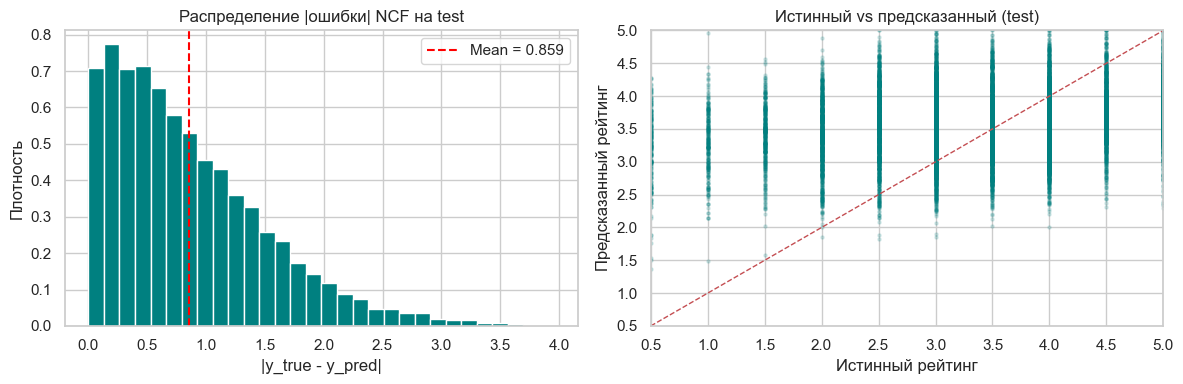

In [12]:
# Ошибки на test
test_with_errors = test.copy()
test_with_errors['pred']  = test_preds
test_with_errors['error'] = np.abs(y_test - test_preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(test_with_errors['error'], bins=30, color='teal',
             edgecolor='white', density=True)
axes[0].axvline(test_with_errors['error'].mean(), color='red', linestyle='--',
                label=f'Mean = {test_with_errors["error"].mean():.3f}')
axes[0].set_title('Распределение |ошибки| NCF на test')
axes[0].set_xlabel('|y_true - y_pred|')
axes[0].set_ylabel('Плотность')
axes[0].legend()

axes[1].scatter(y_test, test_preds, alpha=0.15, s=5, color='teal')
lims = [0.5, 5.0]
axes[1].plot(lims, lims, 'r--', linewidth=1)
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_xlabel('Истинный рейтинг')
axes[1].set_ylabel('Предсказанный рейтинг')
axes[1].set_title('Истинный vs предсказанный (test)')
plt.tight_layout()
plt.show()

In [13]:
# Топ-10 фильмов с наибольшей средней ошибкой
movie_error = (
    test_with_errors.groupby('movieId')['error']
    .agg(['mean', 'count']).reset_index()
    .rename(columns={'mean': 'mean_error', 'count': 'n_test'})
)
movie_error = movie_error[movie_error['n_test'] >= 3]
top_movie_errors = (
    movie_error.nlargest(10, 'mean_error')
    .merge(movies_enriched[['movieId', 'title']], on='movieId', how='left')
)
top_movie_errors['mean_error'] = top_movie_errors['mean_error'].round(3)
print('Топ-10 фильмов с наибольшей средней |ошибкой| (min 3 оценки в test):')
display(top_movie_errors[['title', 'mean_error', 'n_test']])

# Топ-10 пользователей
user_error = (
    test_with_errors.groupby('userId')['error']
    .agg(['mean', 'count']).reset_index()
    .rename(columns={'mean': 'mean_error', 'count': 'n_test'})
)
user_error = user_error[user_error['n_test'] >= 3]
top_user_errors = user_error.nlargest(10, 'mean_error').copy()
top_user_errors['mean_error'] = top_user_errors['mean_error'].round(3)
print('\nТоп-10 пользователей с наибольшей средней |ошибкой|:')
display(top_user_errors)

Топ-10 фильмов с наибольшей средней |ошибкой| (min 3 оценки в test):


,title,mean_error,n_test
0,Sense and Sensibility (1995),2.538,3
1,"Sting, The (1973)",1.846,4
2,Tootsie (1982),1.826,4
3,Field of Dreams (1989),1.785,6
4,Insurgent (2015),1.769,3
5,Dungeons & Dragons (2000),1.683,3
6,Chronicle (2012),1.653,3
7,Kung Fu Hustle (Gong fu) (2004),1.633,3
8,"Ring, The (2002)",1.629,5
9,Scary Movie 3 (2003),1.615,3



Топ-10 пользователей с наибольшей средней |ошибкой|:


,userId,mean_error,n_test
50,329,2.258,17
72,461,1.548,22
25,153,1.540,138
80,517,1.442,354
96,599,1.331,1987
12,77,1.247,25
19,112,1.222,40
58,365,1.195,179
44,296,1.180,18
38,258,1.156,19


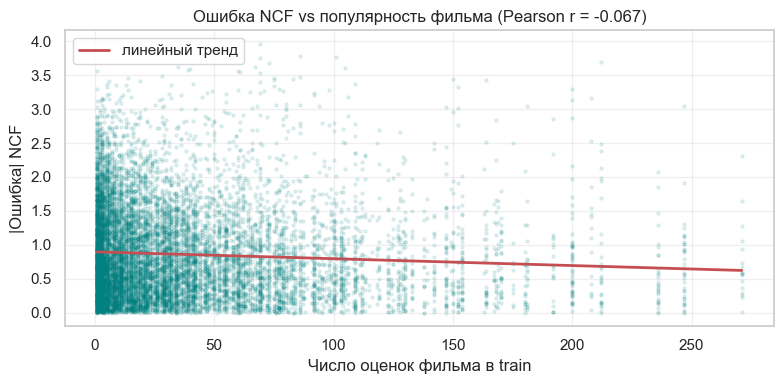

Pearson r (ошибка vs популярность): -0.0668
Отрицательная корреляция -> популярные фильмы предсказываются точнее (больше данных -> лучше выученные эмбеддинги).


In [14]:
# Корреляция ошибки с популярностью фильма в train
movie_pop_train = (
    train.groupby('movieId').size().reset_index(name='n_ratings_train')
)
error_vs_pop = test_with_errors.merge(movie_pop_train, on='movieId', how='left')

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(error_vs_pop['n_ratings_train'], error_vs_pop['error'],
           alpha=0.1, s=5, color='teal')

x_vals = error_vs_pop['n_ratings_train'].values
y_vals = error_vs_pop['error'].values
mask   = ~np.isnan(x_vals) & ~np.isnan(y_vals)

# np.polyfit returns [slope, intercept] (highest degree first)
slope, intercept = np.polyfit(x_vals[mask], y_vals[mask], 1)
x_line = np.linspace(x_vals[mask].min(), x_vals[mask].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2, label='линейный тренд')

corr = np.corrcoef(x_vals[mask], y_vals[mask])[0, 1]
ax.set_xlabel('Число оценок фильма в train')
ax.set_ylabel('|Ошибка| NCF')
ax.set_title(f'Ошибка NCF vs популярность фильма (Pearson r = {corr:.3f})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Pearson r (ошибка vs популярность): {corr:.4f}')
if corr < 0:
    print('Отрицательная корреляция -> популярные фильмы предсказываются точнее '
          '(больше данных -> лучше выученные эмбеддинги).')

## 9. Сравнение всех моделей

Единый порог релевантности 3.5 для всех моделей, кроме ALS (порог 4.0 — implicit-специфика).
ALS приводится для ориентира, прямое сравнение с ним некорректно.


Popularity (recomputed at threshold 3.5):
{
  "precision@5": 0.27676767676767683,
  "recall@5": 0.03789804834237043,
  "ndcg@5": 0.2838933352399009,
  "hit_rate@5": 0.6161616161616161,
  "precision@10": 0.23333333333333334,
  "recall@10": 0.05548174279890518,
  "ndcg@10": 0.254265372821159,
  "hit_rate@10": 0.6565656565656566,
  "precision@20": 0.20909090909090908,
  "recall@20": 0.09152701830156021,
  "ndcg@20": 0.2409164676772354,
  "hit_rate@20": 0.7373737373737373,
  "coverage@20": 0.020198310686742563
}

Сводная таблица всех моделей (единый порог релевантности 3.5):


,Модель,RMSE,MAE,NDCG@10,Precision@10,Recall@10,HitRate@10,Coverage@20
0,GlobalMean,1.0812,0.8557,NaN,NaN,NaN,NaN,NaN
1,Popularity,NaN,NaN,0.2543,0.2333,0.0555,0.6566,0.0202
2,SVD,1.0512,0.8178,0.2005,0.1879,0.0471,0.5960,0.0222
3,KNN,1.1427,0.8902,0.0573,0.0303,0.0098,0.2424,0.0255
4,LightGBM,1.0524,0.8326,0.0666,0.0424,0.0112,0.3030,0.0920
5,ALS (hybrid),NaN,NaN,0.2895,0.2727,0.0701,0.7576,0.0766
6,NCF,1.0851,0.8591,0.0868,0.0879,0.0217,0.3838,0.0468


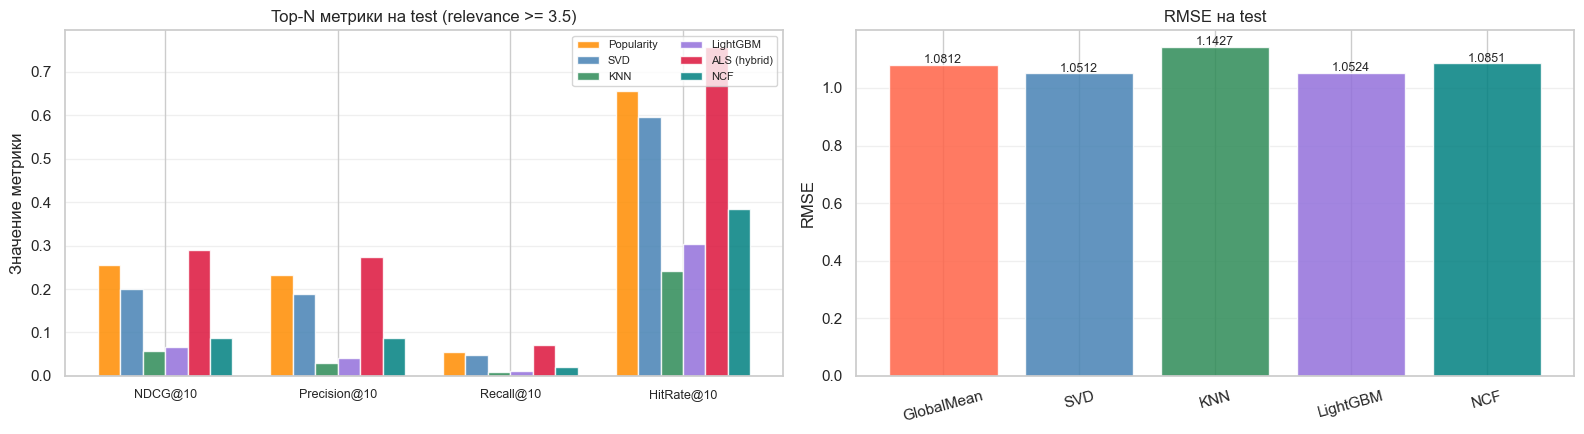

In [ ]:
# ── Загрузка метрик всех моделей ────────────────────────────────────────
with open(MODELS_DIR / 'popularity_metrics.json', 'r', encoding='utf-8') as f:
    pop_metrics = json.load(f)
with open(MODELS_DIR / 'popularity_params.json', 'r', encoding='utf-8') as f:
    pop_params_saved = json.load(f)
with open(MODELS_DIR / 'svd_metrics.json', 'r', encoding='utf-8') as f:
    svd_metrics_loaded = json.load(f)
with open(MODELS_DIR / 'knn_metrics.json', 'r', encoding='utf-8') as f:
    knn_metrics_loaded = json.load(f)
with open(MODELS_DIR / 'lightgbm_metrics.json', 'r', encoding='utf-8') as f:
    lgbm_metrics_loaded = json.load(f)
with open(MODELS_DIR / 'als_metrics.json', 'r', encoding='utf-8') as f:
    als_metrics_loaded = json.load(f)

best_m = pop_params_saved['best_m']
_agg     = train_val.groupby('movieId')['rating'].agg(['count', 'mean'])
_n       = _agg['count']; _mu = _agg['mean']
_C       = float(train_val['rating'].mean())
pop_scores = (_n / (_n + best_m)) * _mu + (best_m / (_n + best_m)) * _C
pop_scores = pop_scores.sort_values(ascending=False)
pop_ranked = pop_scores.index.values

seen_by_user_full = train_val.groupby('userId')['movieId'].apply(set).to_dict()
pop_test_recs_at_35 = {}
for u in test_ground_truth.keys():
    seen = seen_by_user_full.get(u, set())
    pop_test_recs_at_35[u] = [m for m in pop_ranked if m not in seen][:20]

pop_test_metrics_at_35 = evaluate_topn(
    pop_test_recs_at_35, test_ground_truth,
    ks=(5, 10, 20),
    all_items=list(movie_id_map.keys()),
)
print(f'Popularity (recomputed at threshold {RELEVANCE_THRESHOLD}):')
print(json.dumps(pop_test_metrics_at_35, indent=2))


def make_row(name, rating_m=None, topn_m=None):
    def r(d, k):
        return round(float(d[k]), 4) if (d and k in d and d[k] is not None) else None
    return {
        'Модель':       name,
        'RMSE':         r(rating_m, 'rmse'),
        'MAE':          r(rating_m, 'mae'),
        'NDCG@10':      r(topn_m,   'ndcg@10'),
        'Precision@10': r(topn_m,   'precision@10'),
        'Recall@10':    r(topn_m,   'recall@10'),
        'HitRate@10':   r(topn_m,   'hit_rate@10'),
        'Coverage@20':  r(topn_m,   'coverage@20'),
    }


comparison_rows = [
    make_row('GlobalMean',  pop_metrics['global_mean']['test']),
    make_row('Popularity',  topn_m=pop_test_metrics_at_35),
    make_row('SVD',
             svd_metrics_loaded['final']['test_rating'],
             svd_metrics_loaded['final']['test_topn']),
    make_row('KNN',
             knn_metrics_loaded['final']['test_rating'],
             knn_metrics_loaded['final']['test_topn']),
    make_row('LightGBM',
             lgbm_metrics_loaded['final']['test_rating'],
             lgbm_metrics_loaded['final']['test_topn']),
    make_row('ALS (hybrid)', topn_m=als_metrics_loaded['final']['test_topn']),
    make_row('NCF',          ncf_test_rating_metrics, ncf_test_topn_metrics),
]

comparison_df = pd.DataFrame(comparison_rows)
print(f'\nСводная таблица всех моделей (единый порог релевантности {RELEVANCE_THRESHOLD}):')
display(comparison_df)


# ── Визуализация ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

topn_cols  = ['NDCG@10', 'Precision@10', 'Recall@10', 'HitRate@10']
models_cmp = [
    ('Popularity',   'darkorange'),
    ('SVD',          'steelblue'),
    ('KNN',          'seagreen'),
    ('LightGBM',     'mediumpurple'),
    ('ALS (hybrid)', 'crimson'),
    ('NCF',          'teal'),
]
x = np.arange(len(topn_cols))
width = 0.13

for i, (mname, color) in enumerate(models_cmp):
    row_ = comparison_df[comparison_df['Модель'] == mname]
    if row_.empty:
        continue
    row_ = row_.iloc[0]
    vals = [float(row_[c]) if row_[c] is not None else 0.0 for c in topn_cols]
    axes[0].bar(x + i * width, vals, width, label=mname,
                color=color, alpha=0.85, edgecolor='white')

axes[0].set_xticks(x + width * 2.5)
axes[0].set_xticklabels(topn_cols, fontsize=9)
axes[0].set_title(f'Top-N метрики на test (relevance >= {RELEVANCE_THRESHOLD})')
axes[0].set_ylabel('Значение метрики')
axes[0].legend(fontsize=8, ncol=2, loc='upper right')
axes[0].grid(axis='y', alpha=0.3)

# RMSE
rmse_models = ['GlobalMean', 'SVD', 'KNN', 'LightGBM', 'NCF']
rmse_colors = ['tomato', 'steelblue', 'seagreen', 'mediumpurple', 'teal']
rmse_vals = []
rmse_models_valid = []
for m, c in zip(rmse_models, rmse_colors):
    v = comparison_df[comparison_df['Модель'] == m]['RMSE'].iloc[0]
    if v is not None:
        rmse_vals.append(float(v))
        rmse_models_valid.append(m)

bars = axes[1].bar(rmse_models_valid, rmse_vals,
                   color=rmse_colors[:len(rmse_models_valid)],
                   alpha=0.85, edgecolor='white')
axes[1].set_title('RMSE на test')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ncf_vs_all_models.png', dpi=110, bbox_inches='tight')
plt.show()

## 10. Сохранение артефактов


In [16]:
# Модель в формате Keras
final_ncf.save(MODELS_DIR / 'ncf_model.keras')
size_kb = (MODELS_DIR / 'ncf_model.keras').stat().st_size / 1024
print(f"ncf_model.keras сохранена ({size_kb:.1f} KB).")

# Параметры
ncf_params_meta = {
    'random_state':              SEED,
    'best_params':               study.best_params,
    'best_epoch':                best_epoch,
    'best_mlp_hidden':           list(best_mlp_hidden),
    'optuna_n_trials':           OPTUNA_N_TRIALS,
    'optuna_n_trials_note':      (
        f'Установлено {OPTUNA_N_TRIALS} из-за стоимости обучения NCF на CPU; '
        'обосновано в markdown раздела 5'
    ),
    'optuna_sampler':            'TPESampler',
    'optuna_direction':          'minimize',
    'optuna_target':             '-ndcg@10 on val',
    'final_train_strategy':      'train+val; epochs=best_epoch (без EarlyStopping)',
    'relevance_threshold':       RELEVANCE_THRESHOLD,
    'tf_version':                tf.__version__,
    'baseline_train_time_sec':   baseline_train_time,
    'optuna_search_time_sec':    optuna_time,
    'final_train_time_sec':      final_train_time,
    'inference_time_test_topn_sec': inference_time,
}
with open(MODELS_DIR / 'ncf_params.json', 'w', encoding='utf-8') as f:
    json.dump(ncf_params_meta, f, ensure_ascii=False, indent=2)

# Метрики
ncf_metrics = {
    'baseline': {
        'val': baseline_val_metrics,
    },
    'final': {
        'val_best_ndcg10': float(best_ndcg10_val),
        'test_rating':     ncf_test_rating_metrics,
        'test_topn':       ncf_test_topn_metrics,
    },
    'meta': {
        'k_values':            [5, 10, 20],
        'relevance_threshold': RELEVANCE_THRESHOLD,
        'optuna_n_trials':     OPTUNA_N_TRIALS,
        'optuna_target':       'ndcg@10',
        'rating_clip_range':   [0.5, 5.0],
    },
}
with open(MODELS_DIR / 'ncf_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(ncf_metrics, f, ensure_ascii=False, indent=2)

# История trials
trials_df = study.trials_dataframe()
trials_df.to_parquet(MODELS_DIR / 'ncf_optuna_trials.parquet', index=False)

print('Все артефакты сохранены.')
print(f'  Лучший NDCG@10 (val): {best_ndcg10_val:.4f}')
print(f'  RMSE (test):          {ncf_test_rating_metrics["rmse"]:.4f}')
print(f'  NDCG@10 (test):       {ncf_test_topn_metrics["ndcg@10"]:.4f}')
print(f'  Coverage@20 (test):   {ncf_test_topn_metrics.get("coverage@20", 0):.4f}')

ncf_model.keras сохранена (4723.8 KB).
Все артефакты сохранены.
  Лучший NDCG@10 (val): 0.2020
  RMSE (test):          1.0851
  NDCG@10 (test):       0.0868
  Coverage@20 (test):   0.0468


## 11. Итоги

| Что сделано | Результат |
|-------------|-----------|
| NeuMF (GMF + MLP), Optuna 30 trials по NDCG@10 | best NDCG@10 val = 0.2020 |
| Оценка по RMSE/MAE и top-N на test | NDCG@10 test = 0.0868 |
| Сравнение со всеми моделями под порогом 3.5 | NCF уступает SVD и Popularity |

NCF проигрывает более простым моделям — это ожидаемо на 100k рейтингов.
Оригинальная статья He et al. (2017) использовала 10× больше данных.
На MovieLens-1M или крупнее нейросеть раскрывает свой потенциал.

> Следующий шаг — `10_ensemble_als_svd_ncf.ipynb`: объединяем лучшие модели в ансамбль.
